# DrainEye — Сборка датасета дефектов (трещина/коррозия/отсутствие повреждений)

## Шаг 1 — Загружаем kaggle.json

In [1]:
from google.colab import files
import os

print('Загрузи файл kaggle.json')
uploaded = files.upload()

os.makedirs('/root/.config/kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.config/kaggle/kaggle.json')
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)
print('✓ kaggle.json установлен')

Загрузи файл kaggle.json


Saving kaggle.json to kaggle.json
✓ kaggle.json установлен


## Шаг 2 — Скачиваем датасеты

In [1]:
!pip install kaggle -q

!kaggle datasets download aditya068/pipeline-corrosion-dataset -p /content/raw/pipeline_corrosion --unzip
!kaggle datasets download arunrk7/surface-crack-detection      -p /content/raw/surface_crack      --unzip
!kaggle datasets download bsurya27/corrosion-detection         -p /content/raw/corrosion_detection --unzip
!kaggle datasets download wednesday233/corrosion-detect-dataset -p /content/raw/corrosion_detect2  --unzip
!kaggle datasets download oluwaseunad/concrete-and-pavement-crack-images -p /content/raw/pavement_crack --unzip

print('✓ Все датасеты скачаны')

Dataset URL: https://www.kaggle.com/datasets/aditya068/pipeline-corrosion-dataset
License(s): unknown
 96% 349M/362M [00:01<00:00, 195MB/s]
100% 362M/362M [00:01<00:00, 201MB/s]
Dataset URL: https://www.kaggle.com/datasets/arunrk7/surface-crack-detection
License(s): copyright-authors
surface-crack-detection.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/bsurya27/corrosion-detection
License(s): unknown
  0% 0.00/6.04M [00:00<?, ?B/s]
100% 6.04M/6.04M [00:00<00:00, 706MB/s]
Dataset URL: https://www.kaggle.com/datasets/wednesday233/corrosion-detect-dataset
License(s): MIT
  0% 0.00/8.12M [00:00<?, ?B/s]
100% 8.12M/8.12M [00:00<00:00, 805MB/s]
Dataset URL: https://www.kaggle.com/datasets/oluwaseunad/concrete-and-pavement-crack-images
License(s): CC-BY-SA-4.0
 97% 308M/319M [00:00<00:00, 405MB/s]
100% 319M/319M [00:00<00:00, 445MB/s]
✓ Все датасеты скачаны


In [3]:
import os

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

for root, dirs, files_in_dir in os.walk('/content/raw'):
    level = root.replace('/content/raw', '').count(os.sep)
    if level > 4:
        continue
    indent = '  ' * level
    n_imgs = len([f for f in files_in_dir if os.path.splitext(f)[1].lower() in IMG_EXTS])
    label = f'  [{n_imgs} фото]' if n_imgs > 0 else ''
    print(f'{indent}{os.path.basename(root)}/{label}')

raw/
  corrosion_detection/
    train/
      images/  [90 фото]
      labels/
    valid/
      images/  [26 фото]
      labels/
    test/
      images/  [13 фото]
      labels/
  corrosion_detect2/
    corrosion detect/
      images/  [268 фото]
      labels/
  pipeline_corrosion/
    Pipeline Corrosion Dataset/
      train/
        Corroded/  [96 фото]
        Normal/  [96 фото]
      test/
        Corroded/  [25 фото]
        Normal/  [24 фото]
  surface_crack/
    Negative/  [20000 фото]
    Positive/  [20000 фото]
  pavement_crack/
    Negative/  [15000 фото]
    Positive/  [15000 фото]


## Шаг 3 — Собираем датасет

In [4]:
import shutil
import random
from pathlib import Path

# ─── Настройки ────────────────────────────────────────────────
RAW_DIR  = Path('/content/raw')
OUT_DIR  = Path('/content/draineye_dataset')
LIMIT    = 500
SEED     = 42
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
SPLIT    = {'train': 0.70, 'val': 0.15, 'test': 0.15}
# ──────────────────────────────────────────────────────────────

random.seed(SEED)

def collect(folder: Path) -> list:
    if not folder.exists():
        print(f'  ⚠ не найдена: {folder}')
        return []
    return [p for p in folder.rglob('*') if p.suffix.lower() in IMG_EXTS]

# ─── Собираем по классам ──────────────────────────────────────
corrosion_imgs = (
    collect(RAW_DIR / 'pipeline_corrosion/Pipeline Corrosion Dataset/train/Corroded') +
    collect(RAW_DIR / 'pipeline_corrosion/Pipeline Corrosion Dataset/test/Corroded')  +
    collect(RAW_DIR / 'corrosion_detection/train/images')                             +
    collect(RAW_DIR / 'corrosion_detection/valid/images')                             +
    collect(RAW_DIR / 'corrosion_detection/test/images')                              +
    collect(RAW_DIR / 'corrosion_detect2/corrosion detect/images')
)

crack_imgs = (
    collect(RAW_DIR / 'surface_crack/Positive') +
    collect(RAW_DIR / 'pavement_crack/Positive')
)

no_damage_imgs = (
    collect(RAW_DIR / 'surface_crack/Negative')                                        +
    collect(RAW_DIR / 'pavement_crack/Negative')                                       +
    collect(RAW_DIR / 'pipeline_corrosion/Pipeline Corrosion Dataset/train/Normal')    +
    collect(RAW_DIR / 'pipeline_corrosion/Pipeline Corrosion Dataset/test/Normal')
)

print(f'До балансировки:')
print(f'  corrosion  : {len(corrosion_imgs)}')
print(f'  crack      : {len(crack_imgs)}')
print(f'  no_damage  : {len(no_damage_imgs)}')

# ─── Балансировка ─────────────────────────────────────────────
corrosion_imgs = random.sample(corrosion_imgs, min(LIMIT, len(corrosion_imgs)))
crack_imgs     = random.sample(crack_imgs,     min(LIMIT, len(crack_imgs)))
no_damage_imgs = random.sample(no_damage_imgs, min(LIMIT, len(no_damage_imgs)))

# ─── Разбивка на train/val/test ───────────────────────────────
def split(imgs: list) -> dict:
    n = len(imgs)
    n_train = int(n * SPLIT['train'])
    n_val   = int(n * SPLIT['val'])
    return {
        'train': imgs[:n_train],
        'val':   imgs[n_train:n_train + n_val],
        'test':  imgs[n_train + n_val:]
    }

splits = {
    'corrosion': split(corrosion_imgs),
    'crack':     split(crack_imgs),
    'no_damage': split(no_damage_imgs),
}

# ─── Копируем ─────────────────────────────────────────────────
if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)

for cls, parts in splits.items():
    for part, imgs in parts.items():
        dst = OUT_DIR / part / cls
        dst.mkdir(parents=True, exist_ok=True)
        prefix = cls[:3]
        for i, src in enumerate(imgs):
            shutil.copy2(src, dst / f'{prefix}_{i:04d}{src.suffix.lower()}')

# ─── Итог ─────────────────────────────────────────────────────
print(f'\n✓ Датасет собран → {OUT_DIR}')
print(f'{"":10} {"train":>6} {"val":>6} {"test":>6}')
print(f'{"-"*30}')
for cls in ['corrosion', 'crack', 'no_damage']:
    counts = {part: len(list((OUT_DIR / part / cls).glob('*'))) for part in ['train', 'val', 'test']}
    print(f'{cls:10} {counts["train"]:>6} {counts["val"]:>6} {counts["test"]:>6}')
total = {part: sum(len(list((OUT_DIR / part / cls).glob('*'))) for cls in ['corrosion','crack','no_damage']) for part in ['train','val','test']}
print(f'{"-"*30}')
print(f'{"Итого":10} {total["train"]:>6} {total["val"]:>6} {total["test"]:>6}')

До балансировки:
  corrosion  : 518
  crack      : 35000
  no_damage  : 35120

✓ Датасет собран → /content/draineye_dataset
            train    val   test
------------------------------
corrosion     350     75     75
crack         350     75     75
no_damage     350     75     75
------------------------------
Итого        1050    225    225


## Шаг 4 — Проверка: примеры из каждого класса

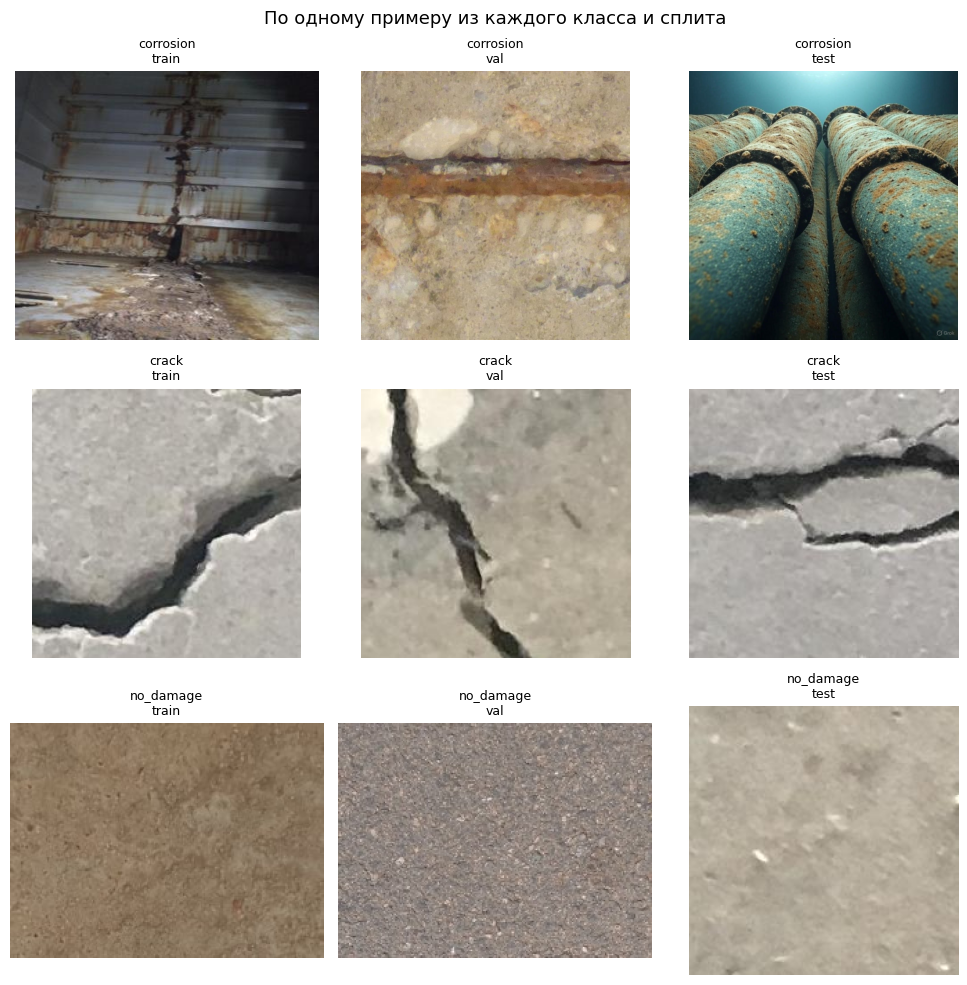

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

classes = ['corrosion', 'crack', 'no_damage']
splits  = ['train', 'val', 'test']

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle('По одному примеру из каждого класса и сплита', fontsize=13)

for row, cls in enumerate(classes):
    for col, split in enumerate(splits):
        imgs = list((OUT_DIR / split / cls).glob('*.*'))
        ax = axes[row][col]
        if imgs:
            ax.imshow(mpimg.imread(random.choice(imgs)))
        ax.set_title(f'{cls}\n{split}', fontsize=9)
        ax.axis('off')

plt.tight_layout()
plt.show()

## Шаг 5 — Архивируем и скачиваем

In [6]:
archive = shutil.make_archive('/content/draineye_dataset', 'zip', '/content', 'draineye_dataset')
size_mb = os.path.getsize(archive) / 1024 / 1024
print(f'✓ Архив готов: {archive}')
print(f'  Размер: {size_mb:.1f} МБ')

✓ Архив готов: /content/draineye_dataset.zip
  Размер: 186.9 МБ


In [ ]:
from google.colab import files
files.download('/content/draineye_defects.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>